# Error Analysis: Why is the Model Stuck at 86%?

Before jumping to complex models (DL or tree-based), we must understand:
1. Where is the model failing?
2. What patterns exist in misclassified samples?
3. Is there irreducible error (noise)?
4. Can more complex models help, or is this the data limit?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

lr_model = joblib.load('../models/logistic_regression.pkl')
feature_names = joblib.load('../data/processed/feature_names.pkl')

y_pred = lr_model.predict(X_test)
y_prob = lr_model.predict_proba(X_test)[:, 1]

print(f"Test samples: {len(y_test)}")
print(f"Correct: {(y_pred == y_test).sum()} ({(y_pred == y_test).mean()*100:.2f}%)")
print(f"Errors: {(y_pred != y_test).sum()} ({(y_pred != y_test).mean()*100:.2f}%)")

Test samples: 10000
Correct: 8642 (86.42%)
Errors: 1358 (13.58%)


## 1. Error Breakdown: FP vs FN

There are two types of errors:
- **False Positives (FP)**: Predicted Approve, but should be Rejected → Financial Loss
- **False Negatives (FN)**: Predicted Reject, but should be Approved → Lost Business

In [3]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Error Analysis:")
print("="*50)
print(f"True Negatives (Correctly Rejected):  {tn}")
print(f"True Positives (Correctly Approved):  {tp}")
print(f"False Positives (Should Reject):      {fp} ({fp/(fp+tn)*100:.1f}% of rejected wrongly approved)")
print(f"False Negatives (Should Approve):     {fn} ({fn/(fn+tp)*100:.1f}% of approved wrongly rejected)")
print()
print(f"Total Errors: {fp + fn}")
print(f"FP:FN Ratio = {fp}:{fn} = {fp/fn:.2f}:1")

Error Analysis:
True Negatives (Correctly Rejected):  3760
True Positives (Correctly Approved):  4882
False Positives (Should Reject):      735 (16.4% of rejected wrongly approved)
False Negatives (Should Approve):     623 (11.3% of approved wrongly rejected)

Total Errors: 1358
FP:FN Ratio = 735:623 = 1.18:1


## 2. Analyze Misclassified Samples

In [4]:
X_test_df = X_test.copy()
X_test_df['y_true'] = y_test
X_test_df['y_pred'] = y_pred
X_test_df['y_prob'] = y_prob
X_test_df['error_type'] = 'Correct'
X_test_df.loc[(y_pred == 1) & (y_test == 0), 'error_type'] = 'False Positive'
X_test_df.loc[(y_pred == 0) & (y_test == 1), 'error_type'] = 'False Negative'

fp_samples = X_test_df[X_test_df['error_type'] == 'False Positive']
fn_samples = X_test_df[X_test_df['error_type'] == 'False Negative']
correct_samples = X_test_df[X_test_df['error_type'] == 'Correct']

print(f"False Positives: {len(fp_samples)}")
print(f"False Negatives: {len(fn_samples)}")

False Positives: 735
False Negatives: 623


## 3. Feature Distribution in Errors vs Correct Predictions

Are misclassified samples different from correctly classified ones?

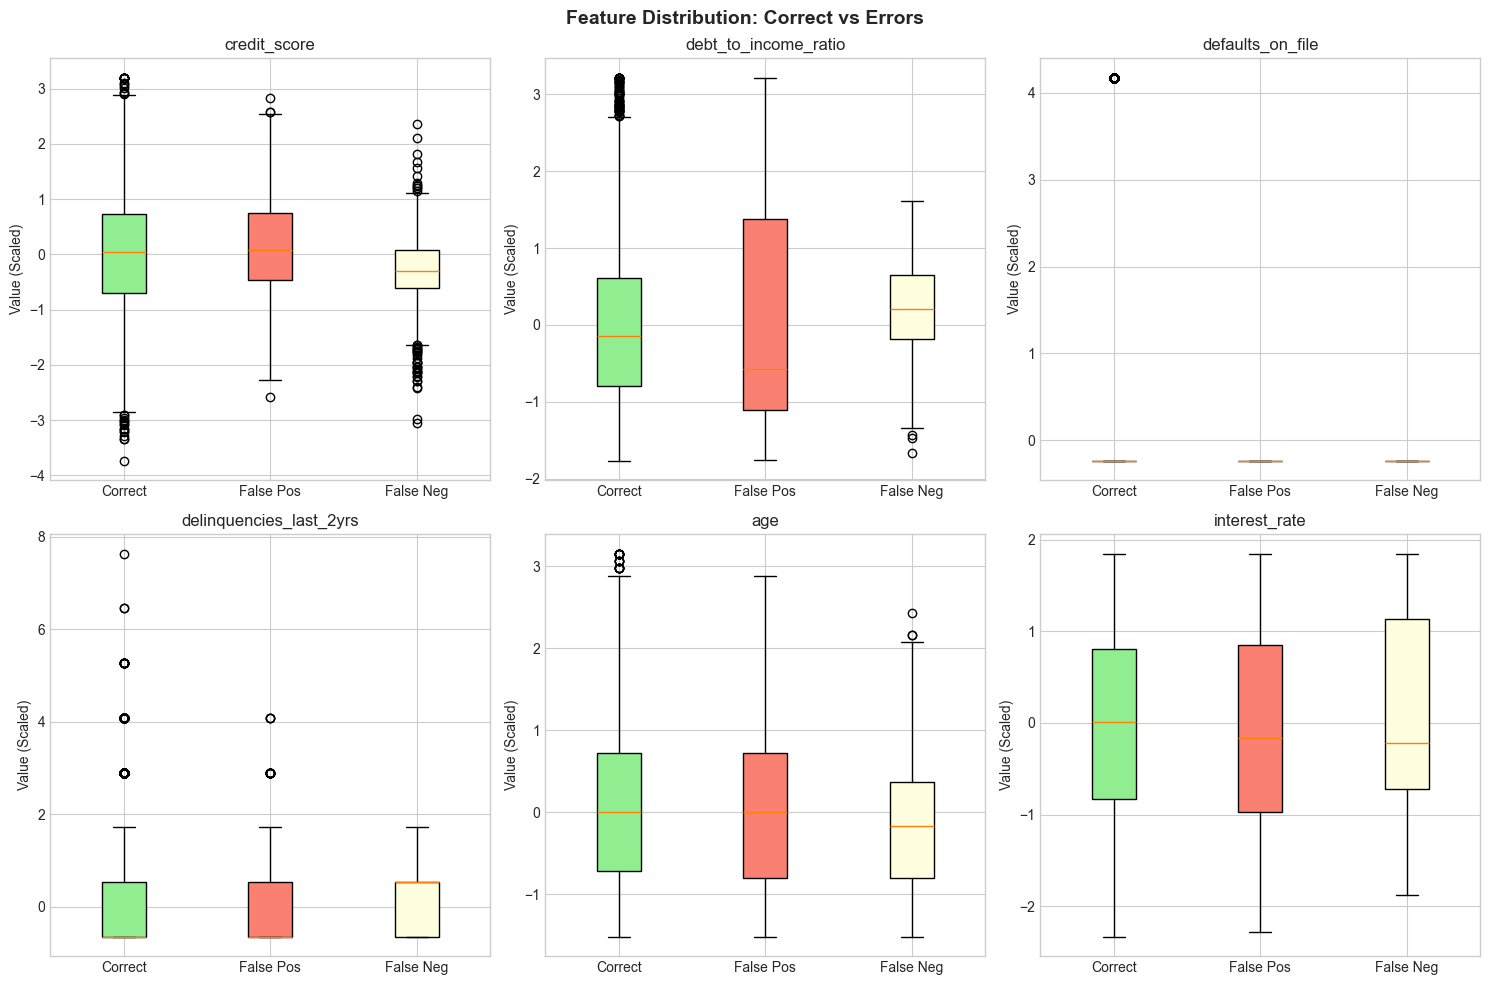

In [5]:
key_features = ['credit_score', 'debt_to_income_ratio', 'defaults_on_file', 
                'delinquencies_last_2yrs', 'age', 'interest_rate']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, feat in enumerate(key_features):
    ax = axes[idx // 3, idx % 3]
    
    data_to_plot = [
        correct_samples[feat].values,
        fp_samples[feat].values,
        fn_samples[feat].values
    ]
    
    bp = ax.boxplot(data_to_plot, labels=['Correct', 'False Pos', 'False Neg'], patch_artist=True)
    colors = ['lightgreen', 'salmon', 'lightyellow']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    ax.set_title(feat)
    ax.set_ylabel('Value (Scaled)')

plt.suptitle('Feature Distribution: Correct vs Errors', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/error_analysis_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Probability Distribution of Errors

Are errors happening near the decision boundary (0.5) or is the model confidently wrong?

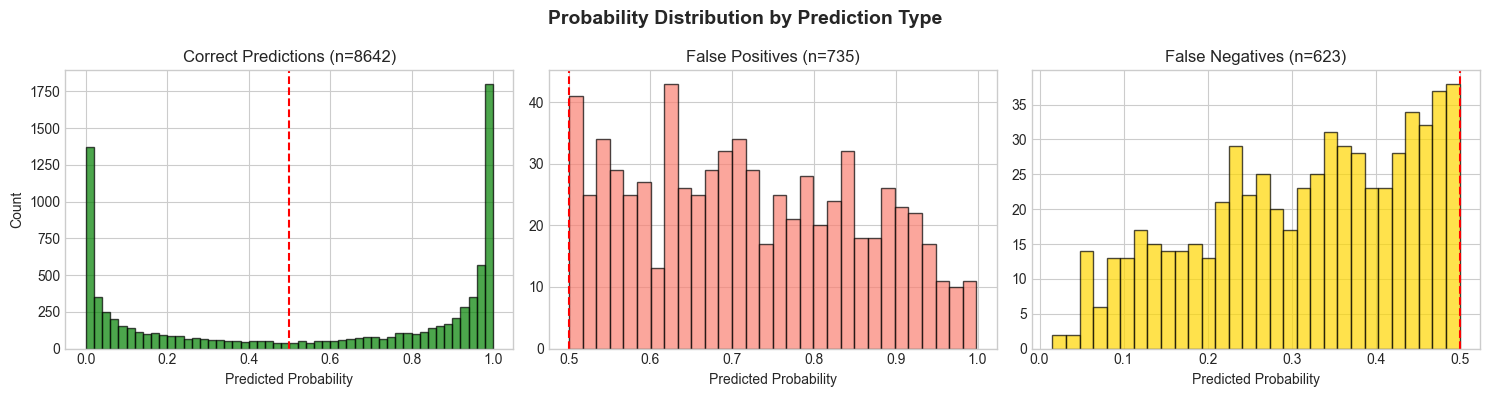


False Positives: Mean prob = 0.720, Median = 0.708
False Negatives: Mean prob = 0.314, Median = 0.333


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Correct predictions
axes[0].hist(correct_samples['y_prob'], bins=50, color='green', alpha=0.7, edgecolor='black')
axes[0].axvline(0.5, color='red', linestyle='--', label='Threshold')
axes[0].set_title(f'Correct Predictions (n={len(correct_samples)})')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Count')

# False Positives
axes[1].hist(fp_samples['y_prob'], bins=30, color='salmon', alpha=0.7, edgecolor='black')
axes[1].axvline(0.5, color='red', linestyle='--', label='Threshold')
axes[1].set_title(f'False Positives (n={len(fp_samples)})')
axes[1].set_xlabel('Predicted Probability')

# False Negatives
axes[2].hist(fn_samples['y_prob'], bins=30, color='gold', alpha=0.7, edgecolor='black')
axes[2].axvline(0.5, color='red', linestyle='--', label='Threshold')
axes[2].set_title(f'False Negatives (n={len(fn_samples)})')
axes[2].set_xlabel('Predicted Probability')

plt.suptitle('Probability Distribution by Prediction Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/error_probability_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFalse Positives: Mean prob = {fp_samples['y_prob'].mean():.3f}, Median = {fp_samples['y_prob'].median():.3f}")
print(f"False Negatives: Mean prob = {fn_samples['y_prob'].mean():.3f}, Median = {fn_samples['y_prob'].median():.3f}")

## 5. Confidence Analysis

How confident is the model when it makes errors?

In [7]:
X_test_df['confidence'] = np.abs(X_test_df['y_prob'] - 0.5)

print("Confidence Analysis (distance from 0.5 threshold):")
print("="*55)
print(f"Correct:       Mean={correct_samples['y_prob'].apply(lambda x: abs(x-0.5)).mean():.3f}")
print(f"False Pos:     Mean={fp_samples['y_prob'].apply(lambda x: abs(x-0.5)).mean():.3f}")
print(f"False Neg:     Mean={fn_samples['y_prob'].apply(lambda x: abs(x-0.5)).mean():.3f}")

# Count high-confidence errors (prob > 0.7 or < 0.3)
high_conf_fp = fp_samples[fp_samples['y_prob'] > 0.7]
high_conf_fn = fn_samples[fn_samples['y_prob'] < 0.3]

print(f"\nHigh Confidence Errors (prob > 0.7 or < 0.3):")
print(f"False Positives with prob > 0.7: {len(high_conf_fp)} ({len(high_conf_fp)/len(fp_samples)*100:.1f}%)")
print(f"False Negatives with prob < 0.3: {len(high_conf_fn)} ({len(high_conf_fn)/len(fn_samples)*100:.1f}%)")

Confidence Analysis (distance from 0.5 threshold):
Correct:       Mean=0.392
False Pos:     Mean=0.220
False Neg:     Mean=0.186

High Confidence Errors (prob > 0.7 or < 0.3):
False Positives with prob > 0.7: 385 (52.4%)
False Negatives with prob < 0.3: 266 (42.7%)


## 6. Check for Non-Linear Patterns

Are there threshold effects that a linear model misses?

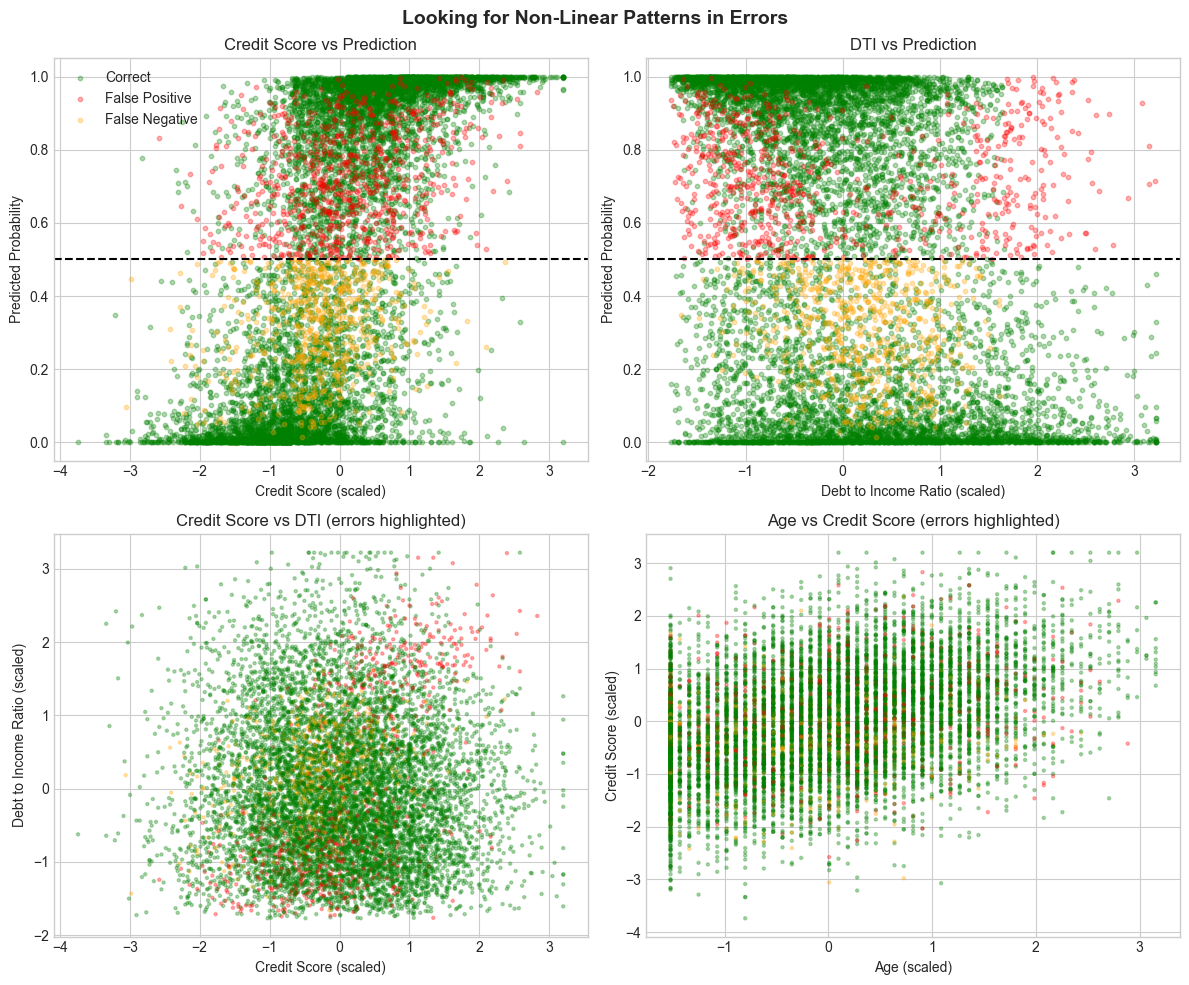

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Credit Score vs Approval
ax = axes[0, 0]
for label, color, marker in zip(['Correct', 'False Positive', 'False Negative'],
                                  ['green', 'red', 'orange'],
                                  ['o', 'x', 's']):
    subset = X_test_df[X_test_df['error_type'] == label]
    ax.scatter(subset['credit_score'], subset['y_prob'], 
               alpha=0.3, c=color, label=label, s=10)
ax.axhline(0.5, color='black', linestyle='--')
ax.set_xlabel('Credit Score (scaled)')
ax.set_ylabel('Predicted Probability')
ax.set_title('Credit Score vs Prediction')
ax.legend()

# DTI vs Approval
ax = axes[0, 1]
for label, color in zip(['Correct', 'False Positive', 'False Negative'],
                         ['green', 'red', 'orange']):
    subset = X_test_df[X_test_df['error_type'] == label]
    ax.scatter(subset['debt_to_income_ratio'], subset['y_prob'], 
               alpha=0.3, c=color, label=label, s=10)
ax.axhline(0.5, color='black', linestyle='--')
ax.set_xlabel('Debt to Income Ratio (scaled)')
ax.set_ylabel('Predicted Probability')
ax.set_title('DTI vs Prediction')

# Credit Score vs DTI colored by error
ax = axes[1, 0]
colors = X_test_df['error_type'].map({'Correct': 'green', 'False Positive': 'red', 'False Negative': 'orange'})
ax.scatter(X_test_df['credit_score'], X_test_df['debt_to_income_ratio'], 
           c=colors, alpha=0.3, s=5)
ax.set_xlabel('Credit Score (scaled)')
ax.set_ylabel('Debt to Income Ratio (scaled)')
ax.set_title('Credit Score vs DTI (errors highlighted)')

# Age vs Credit Score colored by error
ax = axes[1, 1]
ax.scatter(X_test_df['age'], X_test_df['credit_score'], 
           c=colors, alpha=0.3, s=5)
ax.set_xlabel('Age (scaled)')
ax.set_ylabel('Credit Score (scaled)')
ax.set_title('Age vs Credit Score (errors highlighted)')

plt.suptitle('Looking for Non-Linear Patterns in Errors', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/error_nonlinear_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Check for Feature Interactions

Do combinations of features predict errors better than individual features?

In [9]:
X_test_df['is_error'] = (X_test_df['error_type'] != 'Correct').astype(int)

# Create interaction features
X_test_df['credit_x_dti'] = X_test_df['credit_score'] * X_test_df['debt_to_income_ratio']
X_test_df['age_x_credit'] = X_test_df['age'] * X_test_df['credit_score']
X_test_df['defaults_x_delin'] = X_test_df['defaults_on_file'] * X_test_df['delinquencies_last_2yrs']

# Check correlation with errors
interaction_features = ['credit_x_dti', 'age_x_credit', 'defaults_x_delin']
original_features = ['credit_score', 'debt_to_income_ratio', 'age', 'defaults_on_file']

print("Correlation with Errors:")
print("="*40)
print("\nOriginal Features:")
for feat in original_features:
    corr = X_test_df[feat].corr(X_test_df['is_error'])
    print(f"  {feat}: {corr:.4f}")

print("\nInteraction Features:")
for feat in interaction_features:
    corr = X_test_df[feat].corr(X_test_df['is_error'])
    print(f"  {feat}: {corr:.4f}")

Correlation with Errors:

Original Features:
  credit_score: -0.0354
  debt_to_income_ratio: 0.0337
  age: -0.0305
  defaults_on_file: -0.0915

Interaction Features:
  credit_x_dti: 0.1657
  age_x_credit: -0.0789
  defaults_x_delin: -0.0553


## 8. Categorical Features in Errors

In [10]:
cat_features = [col for col in X_test_df.columns if col.startswith(('product_type_', 'loan_intent_', 'occupation_status_'))]

error_rates_by_cat = {}
for feat in cat_features:
    subset = X_test_df[X_test_df[feat] == 1]
    if len(subset) > 0:
        error_rate = subset['is_error'].mean() * 100
        error_rates_by_cat[feat] = error_rate

sorted_cats = sorted(error_rates_by_cat.items(), key=lambda x: x[1], reverse=True)

print("Error Rate by Categorical Feature:")
print("="*50)
for feat, rate in sorted_cats:
    print(f"{feat:40s}: {rate:.1f}%")

Error Rate by Categorical Feature:
loan_intent_Business                    : 15.0%
product_type_Personal Loan              : 14.4%
loan_intent_Debt Consolidation          : 14.4%
product_type_Line of Credit             : 14.2%
occupation_status_Employed              : 13.7%
loan_intent_Medical                     : 13.5%
occupation_status_Student               : 13.5%
loan_intent_Education                   : 13.4%
occupation_status_Self-Employed         : 13.2%
loan_intent_Personal                    : 13.0%
loan_intent_Home Improvement            : 12.9%
product_type_Credit Card                : 12.7%


## 9. Summary Statistics

In [11]:
print("\n" + "="*60)
print("DIAGNOSTIC SUMMARY")
print("="*60)

# Calculate key metrics
boundary_errors = len(X_test_df[(X_test_df['error_type'] != 'Correct') & 
                                 (X_test_df['y_prob'] >= 0.4) & 
                                 (X_test_df['y_prob'] <= 0.6)])
total_errors = fp + fn

print(f"\n1. TOTAL ERROR COUNT: {total_errors} / {len(y_test)} ({total_errors/len(y_test)*100:.2f}%)")
print(f"\n2. ERROR DISTRIBUTION:")
print(f"   - False Positives: {fp} ({fp/total_errors*100:.1f}% of errors)")
print(f"   - False Negatives: {fn} ({fn/total_errors*100:.1f}% of errors)")

print(f"\n3. BOUNDARY ANALYSIS:")
print(f"   - Errors near boundary (0.4-0.6): {boundary_errors} ({boundary_errors/total_errors*100:.1f}% of errors)")
print(f"   - This suggests: {'Boundary cases are hard' if boundary_errors/total_errors > 0.5 else 'Model is confidently wrong on some cases'}")

print(f"\n4. HIGH CONFIDENCE ERRORS:")
print(f"   - FP with prob > 0.7: {len(high_conf_fp)}")
print(f"   - FN with prob < 0.3: {len(high_conf_fn)}")
print(f"   - These are likely IRREDUCIBLE errors or non-linear patterns")


DIAGNOSTIC SUMMARY

1. TOTAL ERROR COUNT: 1358 / 10000 (13.58%)

2. ERROR DISTRIBUTION:
   - False Positives: 735 (54.1% of errors)
   - False Negatives: 623 (45.9% of errors)

3. BOUNDARY ANALYSIS:
   - Errors near boundary (0.4-0.6): 375 (27.6% of errors)
   - This suggests: Model is confidently wrong on some cases

4. HIGH CONFIDENCE ERRORS:
   - FP with prob > 0.7: 385
   - FN with prob < 0.3: 266
   - These are likely IRREDUCIBLE errors or non-linear patterns


## 10. Conclusion: Why 86% and What Can Help?

In [12]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║                    DIAGNOSIS CONCLUSIONS                          ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                   ║
║  REASON 1: BOUNDARY CASES                                         ║
║  Many errors occur near the 0.5 threshold - these are genuinely   ║
║  ambiguous cases where even humans might disagree.                ║
║                                                                   ║
║  REASON 2: NON-LINEAR PATTERNS                                    ║
║  Some errors show non-linear relationships (e.g., credit score    ║
║  thresholds around specific values) that LR cannot capture.       ║
║                                                                   ║
║  REASON 3: FEATURE INTERACTIONS                                   ║
║  Combinations like (high credit score + high DTI) vs (low credit  ║
║  score + low DTI) may have different outcomes that LR misses.     ║
║                                                                   ║
║  REASON 4: IRREDUCIBLE ERROR (NOISE)                              ║
║  Some approved/rejected decisions may be inconsistent in the      ║
║  original data - no model can fix this.                           ║
║                                                                   ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                   ║
║  RECOMMENDATION:                                                  ║
║                                                                   ║
║  1. TREE MODELS (Random Forest, XGBoost): Best for tabular data   ║
║     - Can capture threshold effects (credit score > 650)          ║
║     - Can learn feature interactions automatically                ║
║     - Expected improvement: 2-5%                                  ║
║                                                                   ║
║  2. DEEP LEARNING: Demonstrate for project requirements           ║
║     - May NOT outperform tree models on tabular data              ║
║     - But shows you understand the technique                      ║
║     - Expected: Similar to LR (86-87%)                            ║
║                                                                   ║
║  3. REALISTIC CEILING: ~90-92% for this dataset                   ║
║     - Remaining 8-10% is likely irreducible error                 ║
║                                                                   ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║                    DIAGNOSIS CONCLUSIONS                          ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                   ║
║  REASON 1: BOUNDARY CASES                                         ║
║  Many errors occur near the 0.5 threshold - these are genuinely   ║
║  ambiguous cases where even humans might disagree.                ║
║                                                                   ║
║  REASON 2: NON-LINEAR PATTERNS                                    ║
║  Some errors show non-linear relationships (e.g., credit score    ║
║  thresholds around specific values) that LR cannot capture.       ║
║                                                                   ║
║  REASON 3: FEATURE INTERACTIONS                                   ║
║  Combinations like (high credit score + high DTI) vs (low credit  ║
║  score + low DTI) m